In [1]:
#IPL Data Analysis 
#The notebook uses : Python , Pandas , Matplotlib , Seaborn
#Dataset Used : "ipl_matches.csv"


In [2]:
#import libraries 
#these libraries help in reading data , analyze data and create charts 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
#for styling of charts 
plt.figure(figsize=(8,5))
sns.set_style("whitegrid")

<Figure size 800x500 with 0 Axes>

In [4]:
#loading the "ipl_matches" dataset 
df=pd.read_csv("ipl_matches.csv")
#displaying first 5 rows
df.head()

C:\Users\Arushi Naskar\AppData\Local\Temp\ipykernel_14572\762338745.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("ipl_matches.csv")


,match_id,date,season,event,venue,city,team1,team2,toss_winner,toss_decision,...,non_striker,runs_batter,runs_extras,runs_total,extras_wides,extras_noballs,extras_byes,extras_legbyes,wicket_kind,wicket_player_out
0,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,0,0,0,0,0,0,0,NaN,NaN
1,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,0,0,0,0,0,0,0,NaN,NaN
2,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,4,0,4,0,0,0,0,NaN,NaN
3,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,0,0,0,0,0,0,0,NaN,NaN
4,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,0,2,2,2,0,0,0,NaN,NaN


In [5]:
#understanding dataset 
#inspecting number of rows and columns , column names and missing values
print("Shape of Dataset:",df.shape)
print(df.columns)
print("\nMissing Values:")
print(df.isnull().sum())

Shape of Dataset: (289673, 30)
Index(['match_id', 'date', 'season', 'event', 'venue', 'city', 'team1',
       'team2', 'toss_winner', 'toss_decision', 'winner', 'win_by_runs',
       'win_by_wickets', 'player_of_match', 'innings', 'batting_team', 'over',
       'ball', 'batter', 'bowler', 'non_striker', 'runs_batter', 'runs_extras',
       'runs_total', 'extras_wides', 'extras_noballs', 'extras_byes',
       'extras_legbyes', 'wicket_kind', 'wicket_player_out'],
      dtype='object')

Missing Values:
match_id                  0
date                      0
season                    0
event                     0
venue                     0
city                  12397
team1                     0
team2                     0
toss_winner               0
toss_decision             0
winner                    0
win_by_runs          156126
win_by_wickets       138527
player_of_match         828
innings                   0
batting_team              0
over                      0
ball              

In [7]:
#Question 1 : Do teams that win the toss actually win more matches?
#We will compare 1.Matches where toss winner won the match and 2.Matches where toss winner lost the match 
#create unique match dataframe
matches = df[['match_id' , 'toss_winner' , 'winner']].drop_duplicates()
#toss winner also won match 
matches['toss_win_match_win']=matches['toss_winner']==matches['winner']
#calculate percentage
toss_win_percent=matches['toss_win_match_win'].mean()*100
toss_loss_percent = 100 - toss_win_percent

print("Toss Winner Match Win %:",round(toss_win_percent,2))
print("Toss Loser Match Win %:" , round(toss_loss_percent,2))

Toss Winner Match Win %: 50.49
Toss Loser Match Win %: 49.51


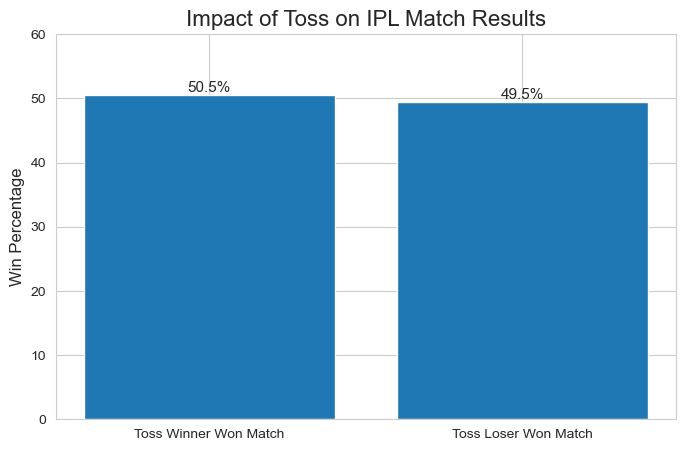

In [10]:
#Chart 1 - Toss Impact Visualization 
labels = ['Toss Winner Won Match', 'Toss Loser Won Match']
values = [toss_win_percent, toss_loss_percent]

plt.figure(figsize=(8,5))

bars = plt.bar(labels, values)

# Titles and labels
plt.title('Impact of Toss on IPL Match Results', fontsize=16)
plt.ylabel('Win Percentage', fontsize=12)
plt.ylim(0, 60)

# Adding percentage labels on top
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f'{height:.1f}%',
        ha='center',
        fontsize=11
    )

plt.show()



In [ ]:
#Based on graph it means : The analysis revealed that toss advantage had minimal impact on IPL match outcomes, with toss-winning teams winning only slightly more matches than toss-losing teams.”
#looking at graph it shows : Toss winner won the match - 50.5%
#toss looser won the match - 49.5%

In [13]:
#Question 2 - Which phase — powerplay, middle overs, or death overs — is most linked to winning?
#Phases - overs 1-6
#middle overs - overs 7 - 15 
#death overs - overs 16-20
#we can compare average runs scored by winning team and losing teams 
# Create phase column
def phase(over):
    if over <= 6:
        return 'Powerplay'
    elif over <= 15:
        return 'Middle Overs'
    else:
        return 'Death Overs'

df['phase'] = df['over'].apply(phase)

# Mark winning team
df['is_winner'] = df['batting_team'] == df['winner']

# Average runs by phase
phase_analysis = df.groupby(['phase', 'is_winner'])['runs_total'].mean().reset_index()

phase_analysis


,phase,is_winner,runs_total
0,Death Overs,False,1.480574
1,Death Overs,True,1.812067
2,Middle Overs,False,1.235257
3,Middle Overs,True,1.399953
4,Powerplay,False,1.193388
5,Powerplay,True,1.345310


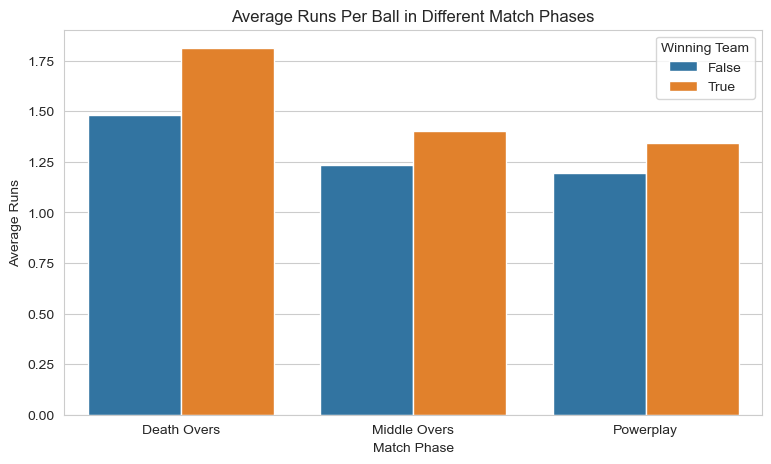

In [14]:
#Chart - 2 : Average Runs Per Phase 
plt.figure(figsize=(9,5))

sns.barplot(
    data=phase_analysis,
    x='phase',
    y='runs_total',
    hue='is_winner'
)

plt.title('Average Runs Per Ball in Different Match Phases')
plt.ylabel('Average Runs')
plt.xlabel('Match Phase')

plt.legend(title='Winning Team')

plt.show()


In [15]:
#the graph shows :  winning teams consistently scored more runs across all match phases compared to losing teams. The largest difference was observed during the death overs, suggesting that strong finishing performances play a major role in determining IPL match outcomes.”

In [16]:
#Question 3 : Who are the top 5 batters and top 5 bowlers across 5 seasons?
#Top 5 batters across seasons
# Selecting last 5 seasons
latest_seasons = sorted(df['season'].astype(str).unique())[-5:]

recent_df = df[df['season'].astype(str).isin(latest_seasons)]

# Top batters
top_batters = recent_df.groupby('batter')['runs_batter'].sum().sort_values(ascending=False).head(5)

print("Top 5 Batters:")
print(top_batters)


Top 5 Batters:
batter
Shubman Gill    2827
V Kohli         2757
JC Buttler      2487
KL Rahul        2401
YBK Jaiswal     2189
Name: runs_batter, dtype: int64


In [17]:
#top 5 bowlers across seasons 

# Count wickets
wickets_df = recent_df[recent_df['wicket_kind'].notna()]

top_bowlers = wickets_df.groupby('bowler')['wicket_kind'].count().sort_values(ascending=False).head(5)

print("Top 5 Bowlers:")
print(top_bowlers)


Top 5 Bowlers:
bowler
YS Chahal         95
Arshdeep Singh    83
HV Patel          83
B Kumar           79
Rashid Khan       78
Name: wicket_kind, dtype: int64


In [18]:
#Combined Performace Table 
batters_table = top_batters.reset_index()
batters_table.columns = ['Batter', 'Runs']

bowlers_table = top_bowlers.reset_index()
bowlers_table.columns = ['Bowler', 'Wickets']

print("\nTop Batters Table")
display(batters_table)

print("\nTop Bowlers Table")
display(bowlers_table)



Top Batters Table


,Batter,Runs
0,Shubman Gill,2827
1,V Kohli,2757
2,JC Buttler,2487
3,KL Rahul,2401
4,YBK Jaiswal,2189



Top Bowlers Table


,Bowler,Wickets
0,YS Chahal,95
1,Arshdeep Singh,83
2,HV Patel,83
3,B Kumar,79
4,Rashid Khan,78


In [ ]:
#From the above table it shows 

The top batter and bowler rankings highlight the most consistent performers across multiple IPL seasons. These players maintained high performance levels over time, contributing significantly to their teams through either run scoring or wicket-taking ability.



Suprising Finding 
“Despite the common belief that winning the toss provides a major advantage in T20 cricket, the analysis showed almost no difference in match 
outcomes between toss winners and toss losers. Instead, teams that performed strongly during the death overs had a much higher probability of winning,
highlighting that finishing strength mattered far more than toss luck.”

Conclusion

This project analyzed IPL match data to understand the impact of toss decisions, phase-wise scoring patterns, and player performances on match 
outcomes. The analysis revealed that winning the toss had only a minimal influence on match results, with toss-winning teams winning almost the same
percentage of matches as toss-losing teams. In contrast, teams that scored more effectively during the death overs showed a significantly higher
probability of winning, highlighting the importance of strong finishing performances in IPL cricket. Additionally, the player analysis identified
the most consistent batters and bowlers across recent seasons based on total runs and wickets. Overall, this project demonstrates how data analysis
and visualization can uncover meaningful insights from sports data and support data-driven understanding of match performance.
